### Overview

PCA plots of sample segregation in all datasets using normalized counts 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pydeseq2.preprocessing import deseq2_norm_fit, deseq2_norm_transform
from sklearn.decomposition import PCA
import random

In [2]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 1. Import and prepare data

In [3]:
# import PAM50 genes
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [4]:
# import raw count files
train = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_raw_counts_subtype_train_80.csv", 
                          header=0, index_col=0)
scanb_hiseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_raw_counts_subtype_test_20.csv", 
                          header=0, index_col=0)
scanb_nextseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_cleaned_data/pam50genes_raw_counts_subtype_scanb_nextseq.csv", 
                          header=0, index_col=0)
tcga_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/pam50genes_raw_counts_subtype_tcga_brca.csv", 
                       header=0, index_col=0)

In [5]:
# check dimension
print(train.shape)
print(scanb_hiseq_test.shape)
print(scanb_nextseq_test.shape)
print(tcga_test.shape)

(2204, 52)
(551, 52)
(276, 51)
(1031, 51)


In [6]:
# check whether the first 50 column names (PAM50 gene ensembl IDs) match
print(train.columns[0:50].equals(scanb_hiseq_test.columns[0:50]))
print(train.columns[0:50].equals(scanb_nextseq_test.columns[0:50]))
print(train.columns[0:50].equals(tcga_test.columns[0:50]))

True
True
True


In [7]:
# check whether the ensemble id column order match with that of in the pam50 df
train.columns[0:50].tolist() == pam50['ensembl_gene_id'].tolist()

True

In [8]:
# extract counts
train_counts = train.iloc[:, 0:50]
scanb_hiseq_test_counts = scanb_hiseq_test.iloc[:, 0:50]
scanb_nextseq_test_counts = scanb_nextseq_test.iloc[:, 0:50]
tcga_test_counts = tcga_test.iloc[:, 0:50]

#### 2. Normalize raw counts using cross-sample normalization pipeline
##### PyDESeq2 median of ratios --> Log2 transformation --> Z-score standardization

In [9]:
# deseq normalize the train set
logMeans_train, filteredGenes_train = deseq2_norm_fit(train_counts)
train_deseq2 = deseq2_norm_transform(train_counts, logMeans_train, filteredGenes_train)[0]
train_deseq2.shape

(2204, 50)

In [10]:
# deseq normalize the test sets using the train set's normalization factors
scanb_hiseq_test_deseq2 = deseq2_norm_transform(scanb_hiseq_test_counts, logMeans_train, filteredGenes_train)[0]
scanb_nextseq_test_deseq2 = deseq2_norm_transform(scanb_nextseq_test_counts, logMeans_train, filteredGenes_train)[0]
tcga_test_deseq2 = deseq2_norm_transform(tcga_test_counts, logMeans_train, filteredGenes_train)[0]

print(scanb_hiseq_test_deseq2.shape)
print(scanb_nextseq_test_deseq2.shape)
print(tcga_test_deseq2.shape)

(551, 50)
(276, 50)
(1031, 50)


In [11]:
# log2 transform the counts
train_log2 = np.log2(train_deseq2 + 1)
scanb_hiseq_test_log2 = np.log2(scanb_hiseq_test_deseq2 + 1)
scanb_nextseq_test_log2 = np.log2(scanb_nextseq_test_deseq2 + 1)
tcga_test_log2 = np.log2(tcga_test_deseq2 + 1)

In [12]:
# standardize the log2 transformed counts of the train set
scaler = StandardScaler()
train_standardized = scaler.fit_transform(train_log2)
train_standardized = pd.DataFrame(train_standardized, index=train_log2.index, columns=train_log2.columns)
train_standardized.shape

(2204, 50)

In [13]:
# standardize the log2 transformed counts of the test sets using the train set-fitted scaler
scanb_hiseq_test_standardized = scaler.transform(scanb_hiseq_test_log2)
scanb_nextseq_test_standardized = scaler.transform(scanb_nextseq_test_log2)
tcga_test_standardized = scaler.transform(tcga_test_log2)

scanb_hiseq_test_standardized = pd.DataFrame(scanb_hiseq_test_standardized, index=scanb_hiseq_test_log2.index, columns=scanb_hiseq_test_log2.columns)
scanb_nextseq_test_standardized = pd.DataFrame(scanb_nextseq_test_standardized, index=scanb_nextseq_test_log2.index, columns=scanb_nextseq_test_log2.columns)
tcga_test_standardized = pd.DataFrame(tcga_test_standardized, index=tcga_test_log2.index, columns=tcga_test_log2.columns)

#### 3. Visualize sample segregation using PCA

In [14]:
# pca transformation
pca = PCA(n_components=2, random_state=seed)

# scanb hiseq training set
pcaComponents_train = pca.fit_transform(train_standardized)
pcaComponents_train = pd.DataFrame(pcaComponents_train, columns=["PC1", "PC2"], index=train_standardized.index)
print(pcaComponents_train.shape)

# scanb hiseq test set
pcaComponents_scanbhiseq_test = pca.transform(scanb_hiseq_test_standardized)
pcaComponents_scanbhiseq_test = pd.DataFrame(pcaComponents_scanbhiseq_test, columns=["PC1", "PC2"], index=scanb_hiseq_test_standardized.index)
print(pcaComponents_scanbhiseq_test.shape)

# scanb nextseq test set
pcaComponents_scanbnextseq_test = pca.transform(scanb_nextseq_test_standardized)
pcaComponents_scanbnextseq_test = pd.DataFrame(pcaComponents_scanbnextseq_test, columns=["PC1", "PC2"], index=scanb_nextseq_test_standardized.index)
print(pcaComponents_scanbnextseq_test.shape)

# tcga-brca test set
pcaComponents_tcga_test = pca.transform(tcga_test_standardized)
pcaComponents_tcga_test = pd.DataFrame(pcaComponents_tcga_test, columns=["PC1", "PC2"], index=tcga_test_standardized.index)
print(pcaComponents_tcga_test.shape)

(2204, 2)
(551, 2)
(276, 2)
(1031, 2)


In [15]:
# check if the indices match
print(train.index.equals(pcaComponents_train.index))
print(scanb_hiseq_test.index.equals(pcaComponents_scanbhiseq_test.index))
print(scanb_nextseq_test.index.equals(pcaComponents_scanbnextseq_test.index))
print(tcga_test.index.equals(pcaComponents_tcga_test.index))

True
True
True
True


In [16]:
# join pca components and subtype
pcaComponents_train_subtype = pcaComponents_train.join(train.loc[:, ['subtype']])
pcaComponents_scanbhiseq_test_subtype = pcaComponents_scanbhiseq_test.join(scanb_hiseq_test.loc[:, ['subtype']])
pcaComponents_scanbnextseq_test_subtype = pcaComponents_scanbnextseq_test.join(scanb_nextseq_test.loc[:, ['subtype']])
pcaComponents_tcga_test_subtype = pcaComponents_tcga_test.join(tcga_test.loc[:, ['subtype']])

In [17]:
# replace Her2 by HER2
pcaComponents_train_subtype['subtype'] = pcaComponents_train_subtype['subtype'].replace({'Her2':'HER2'})
pcaComponents_scanbhiseq_test_subtype['subtype'] = pcaComponents_scanbhiseq_test_subtype['subtype'].replace({'Her2':'HER2'})
pcaComponents_scanbnextseq_test_subtype['subtype'] = pcaComponents_scanbnextseq_test_subtype['subtype'].replace({'Her2':'HER2'})
pcaComponents_tcga_test_subtype['subtype'] = pcaComponents_tcga_test_subtype['subtype'].replace({'Her2':'HER2'})

In [18]:
# define colors for subtype to be used in pca plots
custom_palette = {
    'Basal': '#DA70D6',  
    'HER2': '#00BFFF',  
    'LumA': '#50C878',  
    'LumB': '#FF033E',   
}

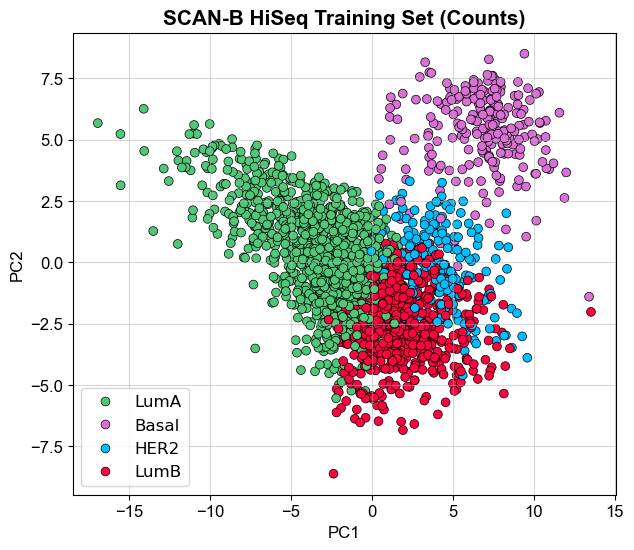

In [19]:
# pca plot of scanb hiseq training set
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pcaComponents_train_subtype["PC1"], 
                y=pcaComponents_train_subtype["PC2"], 
                hue=pcaComponents_train_subtype["subtype"],
                palette=custom_palette, 
                s=40, alpha=1, edgecolor='black', linewidth = 0.5)
plt.xlabel("PC1", fontsize=12, fontfamily='Arial')
plt.ylabel("PC2", fontsize=12, fontfamily='Arial')
plt.title("SCAN-B HiSeq Training Set (Counts)", fontsize=15, fontfamily='Arial', weight='bold')
plt.legend(loc="lower left", ncol=1, fontsize=12)
# plt.xlim(-18, 15)
# plt.ylim(-9, 9)
plt.xticks(fontsize=12, fontfamily='Arial')  
plt.yticks(fontsize=12, fontfamily='Arial') 
plt.grid(alpha=0.5)
# plt.savefig("scanb_hiseq_training_pca_counts.png", dpi=300, bbox_inches="tight")
plt.show()

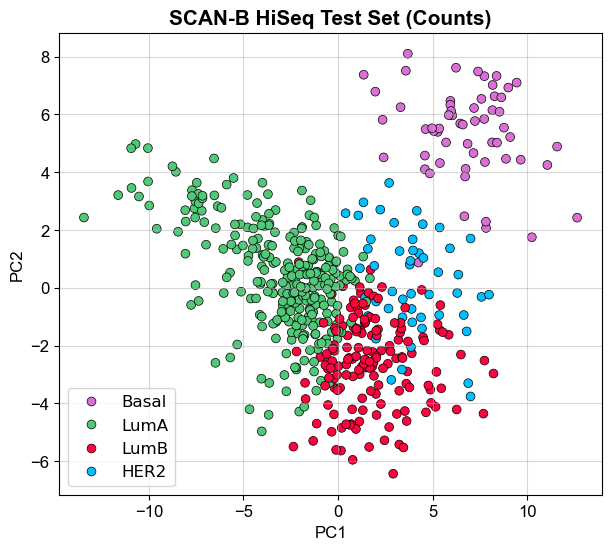

In [20]:
# pca plot of scanb hiseq test set
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pcaComponents_scanbhiseq_test_subtype["PC1"], 
                y=pcaComponents_scanbhiseq_test_subtype["PC2"], 
                hue=pcaComponents_scanbhiseq_test_subtype["subtype"],
                palette=custom_palette, 
                s=40, alpha=1, edgecolor='black', linewidth = 0.5)
plt.xlabel("PC1", fontsize=12, fontfamily='Arial')
plt.ylabel("PC2", fontsize=12, fontfamily='Arial')
plt.title("SCAN-B HiSeq Test Set (Counts)", fontsize=15, fontfamily='Arial', weight='bold')
plt.legend(loc="lower left", ncol=1, fontsize=12)
# plt.xlim(-18, 18)
# plt.ylim(-9, 9)
plt.xticks(fontsize=12, fontfamily='Arial')  
plt.yticks(fontsize=12, fontfamily='Arial') 
plt.grid(alpha=0.5)
# plt.savefig("scanb_hiseq_test_pca_counts.png", dpi=300, bbox_inches="tight")
plt.show()

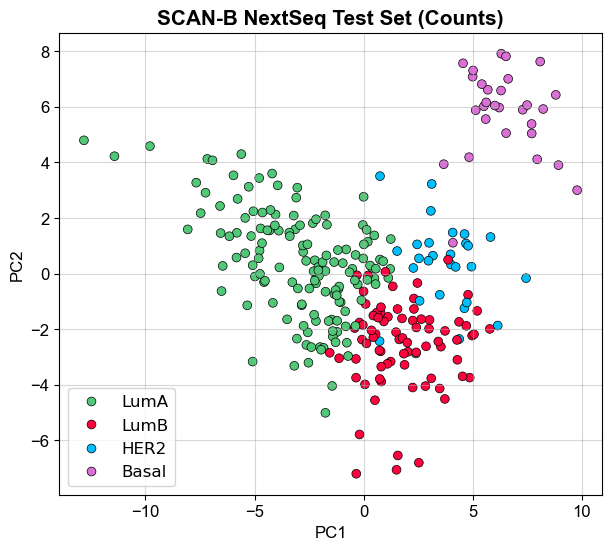

In [21]:
# pca plot of scanb nextseq test set
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pcaComponents_scanbnextseq_test_subtype["PC1"], 
                y=pcaComponents_scanbnextseq_test_subtype["PC2"], 
                hue=pcaComponents_scanbnextseq_test_subtype["subtype"],
                palette=custom_palette, 
                s=40, alpha=1, edgecolor='black', linewidth = 0.5)
plt.xlabel("PC1", fontsize=12, fontfamily='Arial')
plt.ylabel("PC2", fontsize=12, fontfamily='Arial')
plt.title("SCAN-B NextSeq Test Set (Counts)", fontsize=15, fontfamily='Arial', weight='bold')
plt.legend(loc="lower left", ncol=1, fontsize=12)
# plt.xlim(-18, 18)
# plt.ylim(-9, 9)
plt.xticks(fontsize=12, fontfamily='Arial')  
plt.yticks(fontsize=12, fontfamily='Arial') 
plt.grid(alpha=0.5)
# plt.savefig("scanb_nextseq_test_pca_counts.png", dpi=300, bbox_inches="tight")
plt.show()

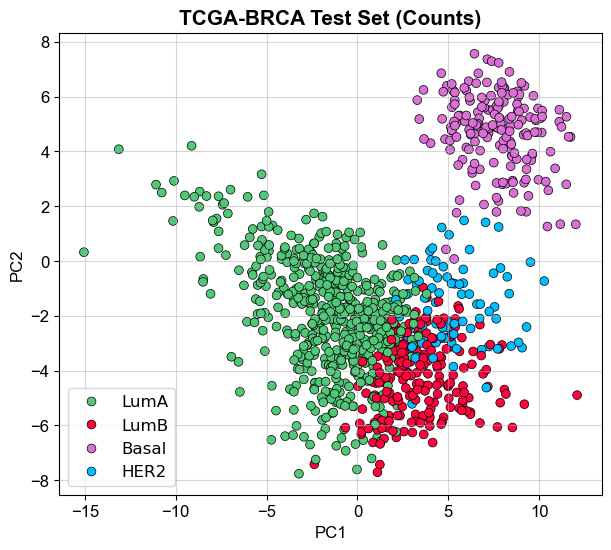

In [22]:
# pca plot of tcga test set
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pcaComponents_tcga_test_subtype["PC1"], 
                y=pcaComponents_tcga_test_subtype["PC2"], 
                hue=pcaComponents_tcga_test_subtype["subtype"],
                palette=custom_palette, 
                s=40, alpha=1, edgecolor='black', linewidth = 0.5)
plt.xlabel("PC1", fontsize=12, fontfamily='Arial')
plt.ylabel("PC2", fontsize=12, fontfamily='Arial')
plt.title("TCGA-BRCA Test Set (Counts)", fontsize=15, fontfamily='Arial', weight='bold')
plt.legend(loc="lower left", ncol=1, fontsize=12)
# plt.xlim(-18, 18)
# plt.ylim(-9, 9)
plt.xticks(fontsize=12, fontfamily='Arial')  
plt.yticks(fontsize=12, fontfamily='Arial') 
plt.grid(alpha=0.5)
# plt.savefig("tcga_test_pca_counts.png", dpi=300, bbox_inches="tight")
plt.show()